# 모델별 검색 성능 막대그래프

이 노트북은 `run_benchmark.sh release search knn` 실행 후 각 인덱스의 `search/search_*.csv`에 저장된 검색 메트릭을 읽어
모델별로 각각 2x3 figure를 그립니다.

색상은 `mxbai`는 빨강 계열, `nomic`은 파랑 계열로 두고, `dim`이 커질수록 더 진한 색을 사용합니다.

포함 지표: `mean_cpus`, `mean_ios`, `mean_io_us`, `qps`, `mean_latency_us`, `latency_999_us`, `recall`

In [72]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook 기준 폴더: /nvme_data/starling/scripts
BASE_DIR = Path('../indices')

# run_benchmark.sh가 쓰는 메트릭 CSV만 탐색
all_csv_files = sorted(BASE_DIR.rglob('search/search_*.csv'))

# 파일명에 '_T1_'가 포함된 실험만 사용
THREAD_TAG = 'T1'
csv_files = [p for p in all_csv_files if f'_{THREAD_TAG}_' in p.name]

print(f'Found {len(all_csv_files)} total search metric CSV files')
print(f'Using {len(csv_files)} files filtered by {THREAD_TAG}')
for p in csv_files[:10]:
    print('-', p)

Found 39 total search metric CSV files
Using 13 files filtered by T1
- ../indices/msmarco_mxbai_128_M32_R48_L100_B0.032/search/search_SQ0_K10_CACHE0_BW2_T1_MEML0_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_mxbai_16_M32_R48_L100_B0.004/search/search_SQ0_K10_CACHE0_BW2_T1_MEML0_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_mxbai_256_M32_R48_L100_B0.064/search/search_SQ0_K10_CACHE0_BW2_T1_MEML0_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_mxbai_32_M32_R48_L100_B0.008/search/search_SQ0_K10_CACHE0_BW2_T1_MEML0_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_mxbai_512_M32_R48_L100_B0.128/search/search_SQ0_K10_CACHE0_BW2_T1_MEML0_MEMK_MEM_USE_FREQ0_PS1_USE_RATIO1.0_GP_USE_FREQ{0}_GP_LOCK_NUMS0_GP_CUT4096.csv
- ../indices/msmarco_mxbai_64_M32_R48_L100_B0.016/search/search_SQ0_

In [73]:
def infer_model_and_dim(path: Path):
    index_dir = path.parents[1].name
    m = re.search(r'msmarco_(?P<family>[^_]+)_(?P<dim>[0-9]+)_M', index_dir)
    if not m:
        return None, None, None, index_dir
    family = m.group('family')
    dim = int(m.group('dim'))
    if family.startswith('mxbai'):
        model = 'mxbai'
    elif family.startswith('nomic'):
        model = 'nomic'
    else:
        model = family
    return model, family, dim, index_dir

required_cols = {
    'L',
    'beamwidth',
    'qps',
    'mean_latency_us',
    'latency_999_us',
    'mean_ios',
    'mean_io_us',
    'mean_cpus',
    'recall',
}

rows = []
for f in csv_files:
    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f'[skip] failed to read {f}: {e}')
        continue

    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        print(f'[skip] missing columns {sorted(missing_cols)} in {f}')
        continue

    model, family, dim, index_dir = infer_model_and_dim(f)
    if model is None:
        print(f'[skip] cannot infer model/dim from {f}')
        continue

    row = df.sort_values(['recall', 'L'], ascending=[False, False]).iloc[0].to_dict()
    row['model'] = model
    row['family'] = family
    row['dim'] = dim
    row['index_dir'] = index_dir
    row['source_file'] = str(f)
    rows.append(row)

if not rows:
    raise RuntimeError('No valid search metric CSV rows found. Check BASE_DIR and search/search_*.csv files.')

summary = pd.DataFrame(rows)
summary = (
    summary.sort_values(['model', 'dim', 'recall', 'L'], ascending=[True, True, False, False])
    .groupby(['model', 'dim'], as_index=False)
    .first()
    .sort_values(['model', 'dim'])
    .reset_index(drop=True)
)

display(summary[['model', 'dim', 'L', 'beamwidth', 'qps', 'mean_latency_us', 'latency_999_us', 'mean_ios', 'mean_io_us', 'mean_cpus', 'recall']])

,model,dim,L,beamwidth,qps,mean_latency_us,latency_999_us,mean_ios,mean_io_us,mean_cpus,recall
0,mxbai,16,100.0,2.0,381.389893,2256.7963,3003.0,86.4268,2000.5316,1284.9087,1.800000
1,mxbai,32,100.0,2.0,365.575348,2372.2559,3111.0,89.3945,2091.2266,1250.0827,10.383000
2,mxbai,64,100.0,2.0,382.204407,2316.7511,3584.0,84.2389,2014.5970,1182.1347,27.150000
3,mxbai,128,100.0,2.0,381.278290,2443.5706,3828.0,86.4489,2109.1644,959.9595,45.630001
4,mxbai,256,100.0,2.0,300.250061,3162.1292,34031.0,92.1664,2657.3874,1133.4386,61.581001
5,mxbai,512,100.0,2.0,185.568146,5217.9191,8040.0,107.8787,3566.1688,1477.9004,75.746002
6,nomic,16,100.0,2.0,364.315186,2379.7523,26339.0,82.8833,2117.3426,1283.9098,3.142000
7,nomic,32,100.0,2.0,372.568726,2337.4263,3630.0,86.0210,2054.7715,1210.1317,15.447000
8,nomic,64,100.0,2.0,415.421814,2162.7794,3241.0,80.0122,1899.1883,971.8691,39.403999
9,nomic,128,100.0,2.0,383.933960,2426.4325,3622.0,86.2610,2091.8387,952.3522,56.022999


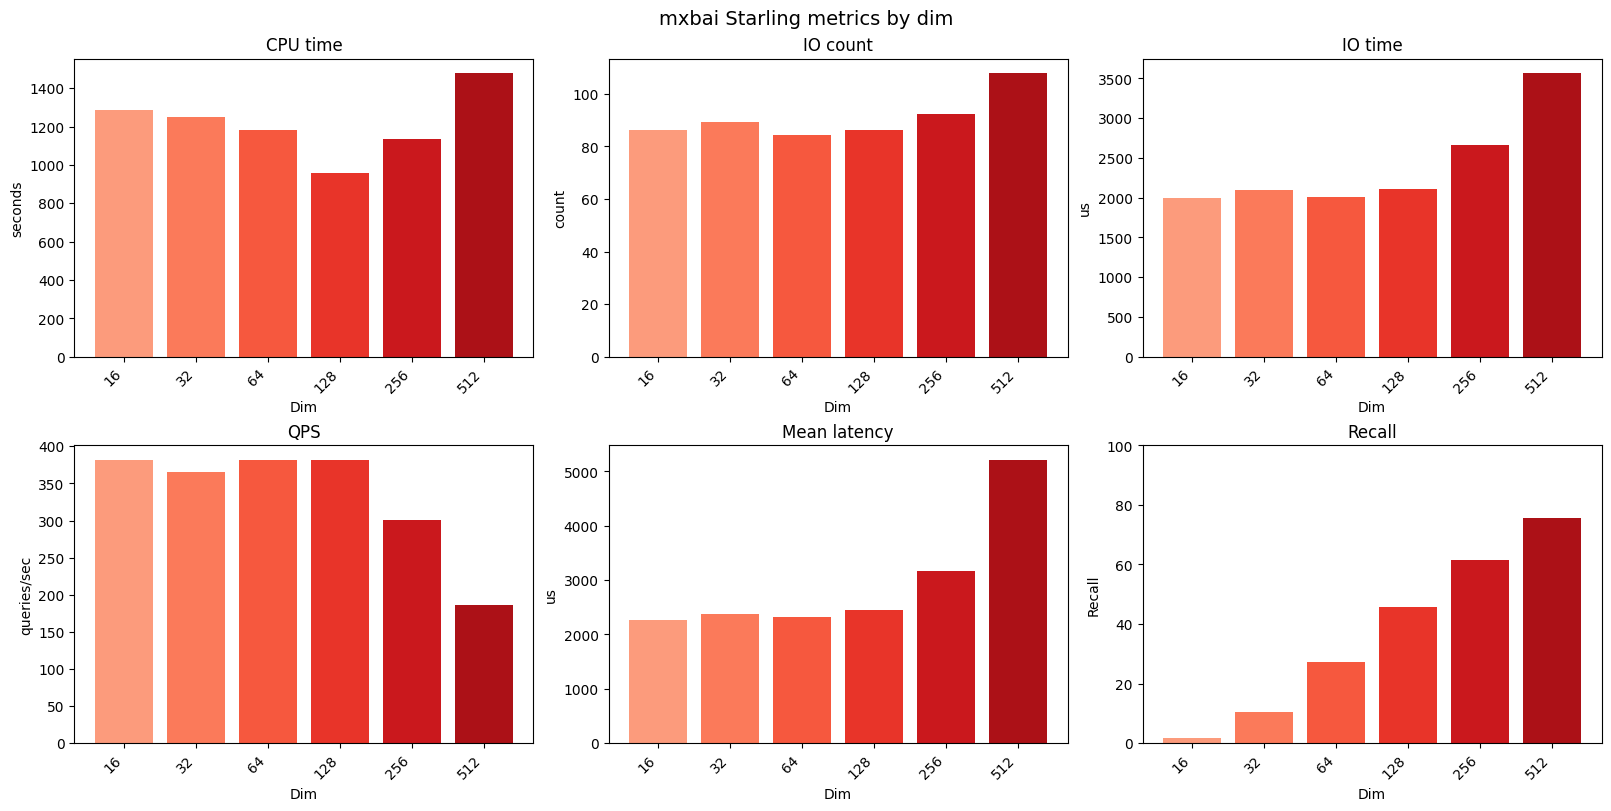

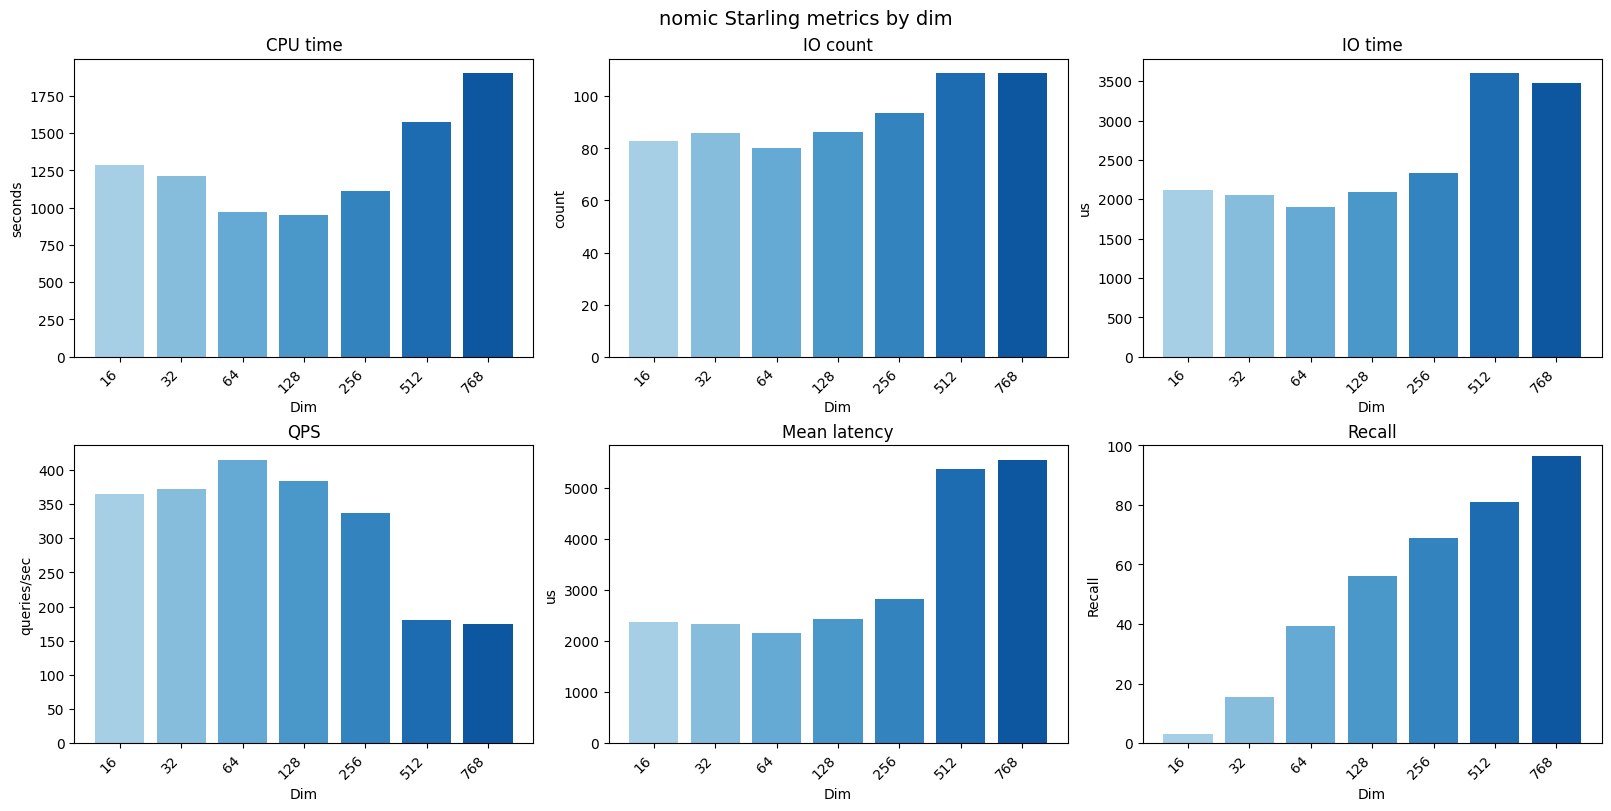

In [74]:
for model, model_df in summary.groupby('model', sort=False):
    plot_df = model_df.sort_values('dim').reset_index(drop=True)
    x_labels = plot_df['dim'].astype(str).tolist()
    x = range(len(plot_df))

    if model == 'mxbai':
        cmap = plt.cm.Reds
    elif model == 'nomic':
        cmap = plt.cm.Blues
    else:
        cmap = plt.cm.Greys

    if len(plot_df) == 1:
        colors = [cmap(0.75)]
    else:
        colors = [cmap(v) for v in np.linspace(0.35, 0.85, len(plot_df))]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
    fig.suptitle(f'{model} Starling metrics by dim', fontsize=14)

    axes[0, 0].bar(x, plot_df['mean_cpus'], color=colors)
    axes[0, 0].set_title('CPU time')
    axes[0, 0].set_xticks(list(x), x_labels, rotation=45, ha='right')
    axes[0, 0].set_xlabel('Dim')
    axes[0, 0].set_ylabel('seconds')

    axes[0, 1].bar(x, plot_df['mean_ios'], color=colors)
    axes[0, 1].set_title('IO count')
    axes[0, 1].set_xticks(list(x), x_labels, rotation=45, ha='right')
    axes[0, 1].set_xlabel('Dim')
    axes[0, 1].set_ylabel('count')

    axes[0, 2].bar(x, plot_df['mean_io_us'], color=colors)
    axes[0, 2].set_title('IO time')
    axes[0, 2].set_xticks(list(x), x_labels, rotation=45, ha='right')
    axes[0, 2].set_xlabel('Dim')
    axes[0, 2].set_ylabel('us')

    axes[1, 0].bar(x, plot_df['qps'], color=colors)
    axes[1, 0].set_title('QPS')
    axes[1, 0].set_xticks(list(x), x_labels, rotation=45, ha='right')
    axes[1, 0].set_xlabel('Dim')
    axes[1, 0].set_ylabel('queries/sec')

    axes[1, 1].bar(x, plot_df['mean_latency_us'], color=colors)
    axes[1, 1].set_title('Mean latency')
    axes[1, 1].set_xticks(list(x), x_labels, rotation=45, ha='right')
    axes[1, 1].set_xlabel('Dim')
    axes[1, 1].set_ylabel('us')

    axes[1, 2].bar(x, plot_df['recall'], color=colors)
    axes[1, 2].set_title('Recall')
    axes[1, 2].set_xticks(list(x), x_labels, rotation=45, ha='right')
    axes[1, 2].set_xlabel('Dim')
    axes[1, 2].set_ylabel('Recall')
    axes[1, 2].set_ylim(0, 100 if plot_df['recall'].max() > 1.5 else 1.0)

    plt.show()